# Participant-level behavior frequencies in the first round

This notebook analyzes only `round_no == 1`, the first non-initial experimental round, and excludes observations where `majority_response` is empty. Each participant is represented by a binary percentage (100% for the behavior observed in round 1 and 0% for the other behaviors). It plots the four majority-based `classification_majority` behaviors in a 2 × 4 grid: rows are $\beta$ and columns are $p_{anti}$. Within each behavior, nonpolitical framing (`framing = 1`) is light and political framing (`framing = 2`) is dark.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

DATA_PATH = Path('../Clean_files/07_combined_classified.csv')
OUTPUT_PATH = Path('Figure_6.png')

BEHAVIORS = [
    'anticonforming_move',
    'anticonforming_stay',
    'conforming_move',
    'conforming_stay',
]
BEHAVIOR_LABELS = {
    'anticonforming_move': 'anticonforming\nmove',
    'anticonforming_stay': 'anticonforming\nstay',
    'conforming_move': 'conforming\nmove',
    'conforming_stay': 'conforming\nstay',
}
X_TICK_LABELS = ['move', 'stay', 'move', 'stay']
X_GROUP_LABELS = [(0.5, 'anticonforming'), (2.5, 'conforming')]
FRAMING_LABELS = {1: 'nonpolitical', 2: 'political'}
P_ANTI_VALUES = [99.0, 0.0, 0.5, 1.0]
P_ANTI_LABELS = {99.0: 'control', 0.0: 'p = 0', 0.5: 'p = 0.5', 1.0: 'p = 1'}
BETA_VALUES = [0.0, 0.5]

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 19,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

In [2]:
df = pd.read_csv(DATA_PATH, sep=',', low_memory=False)
required = {'participant_code', 'round_no', 'classification_majority', 'majority_response',
            'framing', 'beta', 'p_anti'}
missing = required.difference(df.columns)
assert not missing, f'Missing required columns: {sorted(missing)}'

# Use only the first non-initial round and exclude observations with no majority.
has_majority = (
    df['majority_response'].notna()
    & df['majority_response'].astype(str).str.strip().ne('')
)
analysis = df.loc[df['round_no'].eq(1) & has_majority, list(required)].copy()
behavior_types = sorted(analysis['classification_majority'].dropna().unique())
assert set(behavior_types) == set(BEHAVIORS), (
    f'Expected only the four majority-based behavior types, found {behavior_types}'
)

participant_groups = ['participant_code', 'framing', 'beta', 'p_anti']
eligible_rounds = (
    analysis.groupby(participant_groups, observed=True).size().rename('eligible_rounds')
)
assert eligible_rounds.eq(1).all(), 'Every included participant must have one eligible first-round observation.'

counts = (
    analysis.groupby(participant_groups + ['classification_majority'], observed=True)
    .size()
    .rename('n_rounds')
    .reset_index()
)
# Keep only participant/group combinations that occur in the data, while adding zero-count behavior types.
participant_index = analysis[participant_groups].drop_duplicates().set_index(participant_groups).index
complete_index = pd.MultiIndex.from_tuples(
    [(*idx, behavior) for idx in participant_index for behavior in BEHAVIORS],
    names=participant_groups + ['classification_majority'],
)
participant_behavior = (
    counts.set_index(participant_groups + ['classification_majority'])
    .reindex(complete_index, fill_value=0)
    .reset_index()
    .merge(eligible_rounds.reset_index(), on=participant_groups, validate='many_to_one')
)
participant_behavior['percentage'] = (
    100 * participant_behavior['n_rounds'] / participant_behavior['eligible_rounds']
)
participant_behavior['framing_label'] = participant_behavior['framing'].map(FRAMING_LABELS)

check = participant_behavior.groupby(participant_groups, observed=True)['percentage'].sum()
assert np.allclose(check, 100), 'Behavior percentages do not sum to 100 for every participant.'

print(f'{len(participant_index):,} participants; behavior types: {behavior_types}')
print(f'Eligible rounds per participant: {eligible_rounds.min()}–{eligible_rounds.max()}')
participant_behavior.head()

1,391 participants; behavior types: ['anticonforming_move', 'anticonforming_stay', 'conforming_move', 'conforming_stay']
Eligible rounds per participant: 1–1


,participant_code,framing,beta,p_anti,classification_majority,n_rounds,eligible_rounds,percentage,framing_label
0,1orgwsba,1,0.5,0.5,anticonforming_move,0,1,0.0,nonpolitical
1,1orgwsba,1,0.5,0.5,anticonforming_stay,0,1,0.0,nonpolitical
2,1orgwsba,1,0.5,0.5,conforming_move,0,1,0.0,nonpolitical
3,1orgwsba,1,0.5,0.5,conforming_stay,1,1,100.0,nonpolitical
4,3y5neugc,1,0.5,0.5,anticonforming_move,0,1,0.0,nonpolitical


In [3]:
# Participant counts in every panel and framing group.
participant_ns = (
    analysis.groupby(['beta', 'p_anti', 'framing'], observed=True)['participant_code']
    .nunique()
    .rename('n_participants')
    .unstack('framing')
    .rename(columns=FRAMING_LABELS)
)
participant_ns

framing      nonpolitical  political
beta p_anti                         
0.0  0.0               80         80
     0.5              120         64
     1.0              112         80
     99.0              80         80
0.5  0.0               88         87
     0.5               80         80
     1.0               96         88
     99.0              88         88

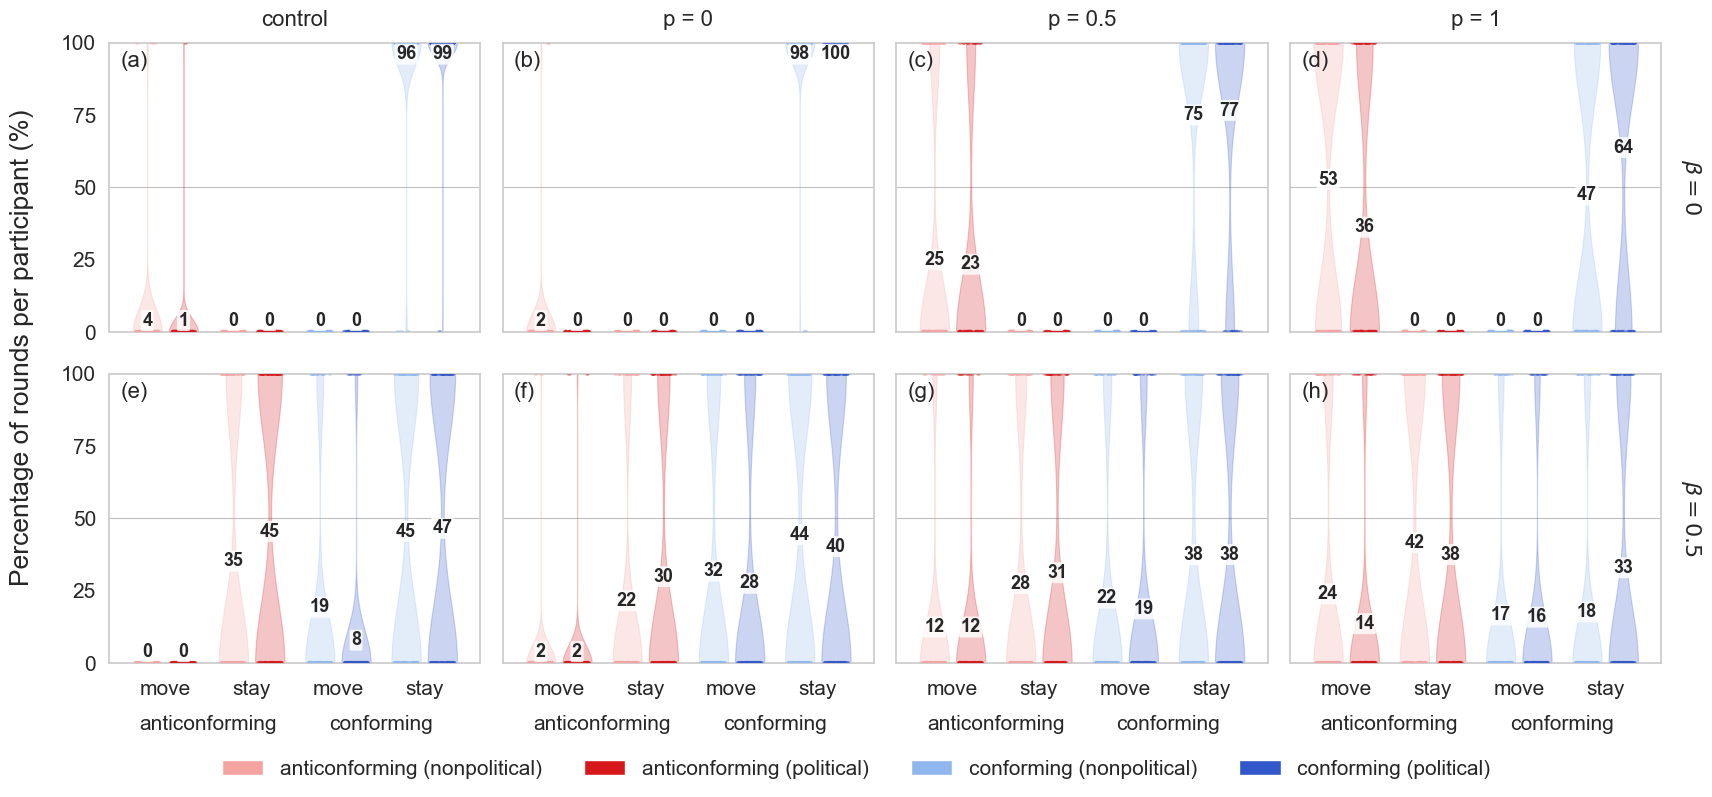

In [4]:
plot_data = participant_behavior.loc[
    participant_behavior['classification_majority'].isin(BEHAVIORS)
].copy()
plot_data['classification_majority'] = pd.Categorical(
    plot_data['classification_majority'], categories=BEHAVIORS, ordered=True
)

# Light = nonpolitical; dark = political. Red shades indicate anticonforming and blue shades conforming.
colors = {
    ('anticonforming_move', 1): '#f5a3a3', ('anticonforming_move', 2): '#d7191c',
    ('anticonforming_stay', 1): '#f5a3a3', ('anticonforming_stay', 2): '#d7191c',
    ('conforming_move', 1): '#91b8ee', ('conforming_move', 2): '#3157c8',
    ('conforming_stay', 1): '#91b8ee', ('conforming_stay', 2): '#3157c8',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
positions = np.arange(len(BEHAVIORS))
offsets = {1: -0.21, 2: 0.21}
violin_width = 0.34
rng = np.random.default_rng(20260715)

for row, beta in enumerate(BETA_VALUES):
    for col, p_anti in enumerate(P_ANTI_VALUES):
        ax = axes[row, col]
        panel = plot_data.loc[(plot_data['beta'] == beta) & (plot_data['p_anti'] == p_anti)]
        for i, behavior in enumerate(BEHAVIORS):
            behavior_means = {}
            for framing in [1, 2]:
                values = panel.loc[
                    (panel['classification_majority'] == behavior) & (panel['framing'] == framing),
                    'percentage',
                ].to_numpy()
                color = colors[(behavior, framing)]
                box_position = i + offsets[framing]
                mean_percentage = np.mean(values)
                behavior_means[framing] = mean_percentage
                violin = ax.violinplot(
                    values, positions=[box_position], widths=violin_width,
                    showmeans=False, showmedians=False, showextrema=False,
                )
                for body in violin['bodies']:
                    body.set_facecolor(color)
                    body.set_edgecolor(color)
                    body.set_linewidth(0.8)
                    body.set_alpha(0.25)
                    body.set_zorder(1)
                jitter = rng.uniform(-violin_width * 0.40, violin_width * 0.40, size=len(values))
                ax.scatter(
                    box_position + jitter, values, s=11, color=color, alpha=0.42,
                    edgecolors='none', zorder=3,
                )

            # The reference figure annotates participant-level means (box lines remain medians).

            for framing in [1, 2]:
                mean_percentage = behavior_means[framing]
                box_position = i + offsets[framing]
                annotation_y = np.clip(mean_percentage, 4, 96)
                ax.annotate(
                    f'{mean_percentage:.0f}', xy=(box_position, mean_percentage),
                    xytext=(box_position, annotation_y), textcoords='data',
                    ha='center', va='center',
                    fontsize=13, fontweight='bold', clip_on=True, zorder=5,
                    bbox=dict(boxstyle='round,pad=0.08', facecolor='white', edgecolor='none', alpha=0.82),
                )
        if row == 0:
            ax.set_title(P_ANTI_LABELS[p_anti], fontsize=16, pad=12)
        panel_label = chr(ord('a') + row * len(P_ANTI_VALUES) + col)
        ax.text(0.03, 0.97, f'({panel_label})', transform=ax.transAxes,
                ha='left', va='top', fontsize=16)
        ax.set_xticks(positions, X_TICK_LABELS)
        ax.tick_params(axis='x', labelsize=15, pad=6)
        if row == len(BETA_VALUES) - 1:
            for group_position, group_label in X_GROUP_LABELS:
                ax.text(group_position, -0.18, group_label,
                        transform=ax.get_xaxis_transform(),
                        ha='center', va='top', fontsize=15)
        ax.set_xlim(-0.65, len(BEHAVIORS) - 0.35)
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100], ['0', '25', '50', '75', '100'])
        ax.grid(False)
        ax.axhline(50, color='0.75', linewidth=0.8, zorder=0)
        for spine in ax.spines.values():
            spine.set_visible(True)
    axes[row, -1].text(1.08, 0.5, rf'$\beta = {beta:g}$', transform=axes[row, -1].transAxes,
                            rotation=270, va='center', ha='center', fontsize=16)

fig.supylabel('Percentage of rounds per participant (%)', fontsize=19, x=0.03, y=0.6, rotation=90)
legend_handles = [
    Patch(facecolor='#f5a3a3', label='anticonforming (nonpolitical)'),
    Patch(facecolor='#d7191c', label='anticonforming (political)'),
    Patch(facecolor='#91b8ee', label='conforming (nonpolitical)'),
    Patch(facecolor='#3157c8', label='conforming (political)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.1))
fig.tight_layout(rect=(0.02, 0.14, 0.98, 1))
fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()
